<a href="https://colab.research.google.com/github/Sivaji063/Regime-Aware-Volatility-Prediction-System/blob/main/regime-aware-volatility-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

import random, os

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {DEVICE}')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'high':    '#E74C3C',
    'low':     '#2ECC71',
    'neutral': '#3498DB',
    'accent':  '#F39C12'
}

✅ Device: cuda


In [4]:
# ────────────────────────────────────────────────────────────
# CELL 3 — Config (Indian Markets)
# ────────────────────────────────────────────────────────────
import datetime
import pytz

# ── Choose your ticker ─────────────────────────────────────────
# NSE Stocks  : 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'
# BSE Stocks  : 'RELIANCE.BO', 'TCS.BO', 'INFY.BO', 'HDFCBANK.BO'
# NSE Indices : '^NSEI'  (NIFTY 50)
# BSE Indices : '^BSESN' (SENSEX)

TICKER          = '^NSEI'      # NIFTY 50
# TICKER        = '^BSESN'    # SENSEX
# TICKER        = 'RELIANCE.NS'  # Reliance NSE
# TICKER        = 'TCS.NS'       # TCS NSE

IST             = pytz.timezone('Asia/Kolkata')
TODAY_IST       = datetime.datetime.now(IST).date()
START_DATE      = (TODAY_IST - datetime.timedelta(days=365*5)).strftime('%Y-%m-%d')
END_DATE        = (TODAY_IST + datetime.timedelta(days=1)).strftime('%Y-%m-%d')

SEQ_LEN         = 30
MASK_RATIO      = 0.20
BATCH_SIZE      = 64
PRETRAIN_EPOCHS = 40
FINETUNE_EPOCHS = 30
LR_PRETRAIN     = 1e-3
LR_FINETUNE     = 5e-4
HIDDEN_SIZE     = 128
NUM_LAYERS      = 2
DROPOUT         = 0.3
TRANS_COST      = 0.001

print('✅ Config loaded')
print(f'   Ticker     : {TICKER}')
print(f'   Exchange   : {"NSE" if ".NS" in TICKER or "NSEI" in TICKER else "BSE"}')
print(f'   Start Date : {START_DATE}')
print(f'   End Date   : {END_DATE}')
print(f'   IST Now    : {datetime.datetime.now(IST).strftime("%d-%m-%Y %H:%M:%S IST")}')

✅ Config loaded
   Ticker     : ^NSEI
   Exchange   : NSE
   Start Date : 2021-03-15
   End Date   : 2026-03-15
   IST Now    : 14-03-2026 01:01:38 IST


In [5]:
# ────────────────────────────────────────────────────────────
# CELL 4 — Download Present/Live Market Data
# ────────────────────────────────────────────────────────────
import datetime

print(f'Downloading {TICKER} from {START_DATE} to {END_DATE}...')
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# Fix for newer yfinance MultiIndex columns
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [col[0].lower() for col in raw.columns]
else:
    raw.columns = [c.lower() for c in raw.columns]

raw.dropna(inplace=True)

print(f'✅ Downloaded {len(raw):,} trading days')
print(f'   From : {raw.index[0].date()}')
print(f'   To   : {raw.index[-1].date()}  ← most recent trading day')
print(f'   Columns: {list(raw.columns)}')
print(raw.tail())

[*********************100%***********************]  1 of 1 completed

✅ Downloaded 1,236 trading days
   From : 2021-03-15
   To   : 2026-03-13  ← most recent trading day
   Columns: ['close', 'high', 'low', 'open', 'volume']
                   close          high           low          open  volume
Date                                                                      
2026-03-09  24028.050781  24078.150391  23697.800781  23868.050781  526900
2026-03-10  24261.599609  24303.800781  24079.949219  24280.800781  444300
2026-03-11  23866.849609  24299.000000  23834.300781  24231.849609  407400
2026-03-12  23639.150391  23833.150391  23556.300781  23674.849609  501000
2026-03-13  23151.099609  23492.400391  23112.000000  23462.500000       0


In [6]:
# ────────────────────────────────────────────────────────────
# CELL 5 — Feature Engineering (With Inf Prevention)
# ────────────────────────────────────────────────────────────

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # Returns
    d['return']      = d['close'].pct_change()
    d['log_return']  = np.log(
        d['close'] / d['close'].shift(1).replace(0, np.nan)
    )

    # Rolling Volatility
    d['vol_20']      = d['return'].rolling(20).std()
    d['vol_5']       = d['return'].rolling(5).std()

    # Moving Averages
    d['ma_10']       = d['close'].rolling(10).mean()
    d['ma_20']       = d['close'].rolling(20).mean()

    # MA Ratio — safe division
    d['ma_ratio']    = np.where(
        d['ma_20'] != 0,
        d['ma_10'] / d['ma_20'],
        1.0                          # default to 1 if ma_20 is zero
    )

    # RSI (14-day)
    delta = d['close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)     # +1e-8 prevents division by zero
    d['rsi'] = 100 - (100 / (1 + rs))

    # Volume Change — safe division
    d['vol_change']  = np.where(
        d['volume'].shift(1) != 0,
        d['volume'].pct_change(),
        0.0
    )

    # High-Low Range — safe division
    d['hl_range']    = np.where(
        d['close'] != 0,
        (d['high'] - d['low']) / d['close'],
        0.0
    )

    # Momentum — safe division
    d['momentum_10'] = np.where(
        d['close'].shift(10) != 0,
        d['close'].pct_change(10),
        0.0
    )

    # ── Clean all inf/nan before returning ────────────────────
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    d.dropna(inplace=True)

    return d


data = build_features(raw)

FEATURE_COLS = [
    'return', 'log_return', 'vol_20', 'vol_5',
    'ma_ratio', 'rsi', 'vol_change', 'hl_range', 'momentum_10'
]

print(f'✅ Features built')
print(f'   Shape   : {data.shape}')
print(f'   Columns : {FEATURE_COLS}')
print(data[FEATURE_COLS].describe().round(4))

✅ Features built
   Shape   : (1216, 16)
   Columns : ['return', 'log_return', 'vol_20', 'vol_5', 'ma_ratio', 'rsi', 'vol_change', 'hl_range', 'momentum_10']
          return  log_return     vol_20      vol_5   ma_ratio        rsi  \
count  1216.0000   1216.0000  1216.0000  1216.0000  1216.0000  1216.0000   
mean      0.0004      0.0004     0.0079     0.0073     1.0022    55.1573   
std       0.0085      0.0085     0.0031     0.0043     0.0104    17.9152   
min      -0.0593     -0.0611     0.0032     0.0011     0.9704     2.0224   
25%      -0.0041     -0.0041     0.0058     0.0046     0.9953    41.8416   
50%       0.0005      0.0005     0.0071     0.0063     1.0027    54.3787   
75%       0.0054      0.0054     0.0094     0.0087     1.0097    67.4046   
max       0.0382      0.0375     0.0189     0.0385     1.0280   100.0000   

       vol_change   hl_range  momentum_10  
count   1216.0000  1216.0000    1216.0000  
mean       0.0562     0.0099       0.0045  
std        0.6072     0.0

Volatility median : 0.00708
Regime distribution:
regime
1    608
0    608
Name: count, dtype: int64


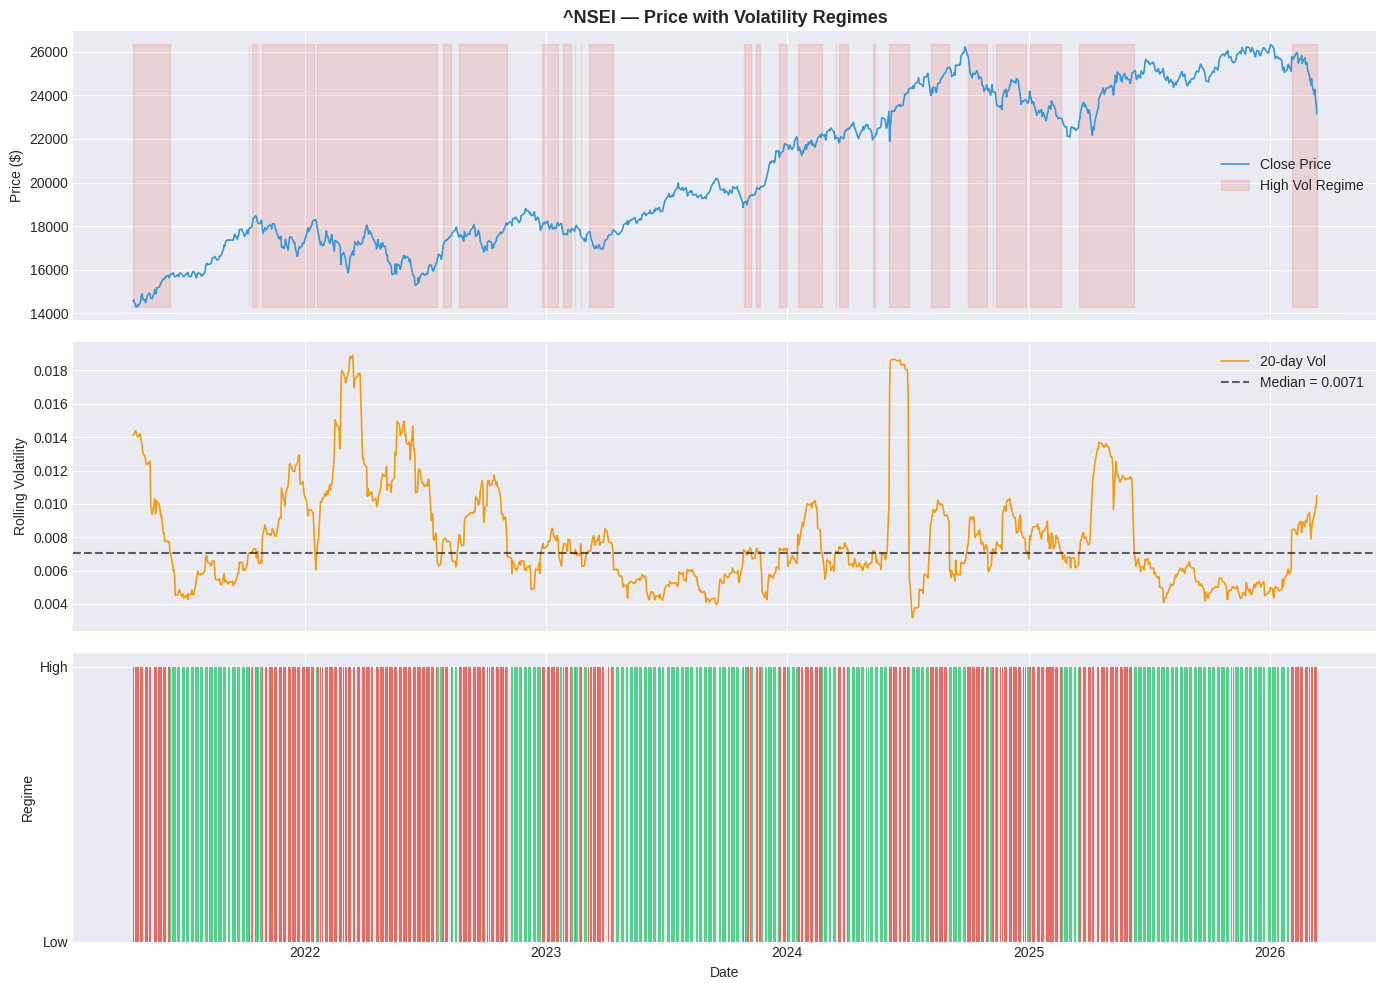

In [7]:
median_vol   = data['vol_20'].median()
data['regime'] = (data['vol_20'] > median_vol).astype(int)   # 1=High, 0=Low

print(f'Volatility median : {median_vol:.5f}')
print(f"Regime distribution:\n{data['regime'].value_counts()}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(data.index, data['close'], color=COLORS['neutral'], lw=1.2, label='Close Price')
axes[0].fill_between(data.index, data['close'].min(), data['close'].max(),
                     where=data['regime'] == 1, alpha=0.15,
                     color=COLORS['high'], label='High Vol Regime')
axes[0].set_title(f'{TICKER} — Price with Volatility Regimes', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].set_ylabel('Price ($)')

axes[1].plot(data.index, data['vol_20'], color=COLORS['accent'], lw=1.2, label='20-day Vol')
axes[1].axhline(median_vol, ls='--', color='black', alpha=0.6,
                label=f'Median = {median_vol:.4f}')
axes[1].set_ylabel('Rolling Volatility'); axes[1].legend()

regime_colors = [COLORS['high'] if r == 1 else COLORS['low'] for r in data['regime']]
axes[2].bar(data.index, 1, color=regime_colors, alpha=0.8, width=1)
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['Low', 'High'])
axes[2].set_ylabel('Regime'); axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [8]:
# ────────────────────────────────────────────────────────────
# CELL 7 — Scale & Build Sequences (With Cleaning)
# ────────────────────────────────────────────────────────────

# ── Step 1: Check for bad values before scaling ────────────────
print("Checking for bad values in features...")
print(f"Shape before cleaning : {data[FEATURE_COLS].shape}")

for col in FEATURE_COLS:
    n_inf  = np.isinf(data[col]).sum()
    n_nan  = np.isnan(data[col]).sum()
    n_large = (np.abs(data[col]) > 1e6).sum()
    if n_inf > 0 or n_nan > 0 or n_large > 0:
        print(f"  ⚠️  {col:15s} | inf={n_inf} | nan={n_nan} | large={n_large}")
    else:
        print(f"  ✅ {col:15s} | clean")

# ── Step 2: Fix all bad values ─────────────────────────────────
data_clean = data[FEATURE_COLS].copy()

# Replace inf and -inf with NaN first
data_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# Clip extreme values to reasonable range (±10 std devs per column)
for col in FEATURE_COLS:
    col_mean = data_clean[col].mean()
    col_std  = data_clean[col].std()
    lower    = col_mean - 10 * col_std
    upper    = col_mean + 10 * col_std
    data_clean[col] = data_clean[col].clip(lower=lower, upper=upper)

# Fill remaining NaN with column median
for col in FEATURE_COLS:
    median_val = data_clean[col].median()
    data_clean[col].fillna(median_val, inplace=True)

# Final check
n_inf_total  = np.isinf(data_clean.values).sum()
n_nan_total  = np.isnan(data_clean.values).sum()
print(f"\nAfter cleaning:")
print(f"  inf values  : {n_inf_total}")
print(f"  nan values  : {n_nan_total}")
print(f"  Shape       : {data_clean.shape}")

if n_inf_total > 0 or n_nan_total > 0:
    print("⚠️  Still have bad values — dropping remaining rows")
    bad_rows   = np.any(np.isinf(data_clean.values) |
                        np.isnan(data_clean.values), axis=1)
    data_clean = data_clean[~bad_rows]
    data       = data[~bad_rows]
    print(f"  Shape after drop : {data_clean.shape}")

print(f"\n✅ Data clean — ready to scale")

# ── Step 3: Scale features ─────────────────────────────────────
scaler       = StandardScaler()
scaled_feats = scaler.fit_transform(data_clean.values)

# Verify scaling output
print(f"\nScaled features stats:")
print(f"  Mean : {scaled_feats.mean():.4f}  (should be ~0)")
print(f"  Std  : {scaled_feats.std():.4f}   (should be ~1)")
print(f"  Min  : {scaled_feats.min():.4f}")
print(f"  Max  : {scaled_feats.max():.4f}")

# ── Step 4: Build sliding-window sequences ─────────────────────
def make_sequences(features: np.ndarray,
                   labels:   np.ndarray,
                   seq_len:  int):
    X, y = [], []
    for i in range(len(features) - seq_len):
        X.append(features[i : i + seq_len])
        y.append(labels[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = make_sequences(
    scaled_feats, data['regime'].values, SEQ_LEN
)
print(f'\nSequences → X: {X_all.shape},  y: {y_all.shape}')

# ── Step 5: Chronological split ────────────────────────────────
n       = len(X_all)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_all[:n_train],                  y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train + n_val],   y_all[n_train:n_train + n_val]
X_test,  y_test  = X_all[n_train + n_val:],           y_all[n_train + n_val:]

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

# ── Step 6: Final sequence check ───────────────────────────────
print(f'\nFinal sequence checks:')
print(f'  X_train inf : {np.isinf(X_train).sum()}')
print(f'  X_val   inf : {np.isinf(X_val).sum()}')
print(f'  X_test  inf : {np.isinf(X_test).sum()}')
print(f'  X_train nan : {np.isnan(X_train).sum()}')
print(f'  X_val   nan : {np.isnan(X_val).sum()}')
print(f'  X_test  nan : {np.isnan(X_test).sum()}')
print(f'\n✅ All sequences clean — ready for model training')

Checking for bad values in features...
Shape before cleaning : (1216, 9)
  ✅ return          | clean
  ✅ log_return      | clean
  ✅ vol_20          | clean
  ✅ vol_5           | clean
  ✅ ma_ratio        | clean
  ✅ rsi             | clean
  ✅ vol_change      | clean
  ✅ hl_range        | clean
  ✅ momentum_10     | clean

After cleaning:
  inf values  : 0
  nan values  : 0
  Shape       : (1216, 9)

✅ Data clean — ready to scale

Scaled features stats:
  Mean : -0.0000  (should be ~0)
  Std  : 1.0000   (should be ~1)
  Min  : -7.2477
  Max  : 12.5863

Sequences → X: (1186, 30, 9),  y: (1186,)
Train : 830
Val   : 177
Test  : 179

Final sequence checks:
  X_train inf : 0
  X_val   inf : 0
  X_test  inf : 0
  X_train nan : 0
  X_val   nan : 0
  X_test  nan : 0

✅ All sequences clean — ready for model training


In [9]:
class SequenceDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]


class MaskedSequenceDataset(Dataset):
    """Returns (masked_seq, original_seq) pairs for self-supervised pretraining."""
    def __init__(self, X, mask_ratio=0.20):
        self.X          = torch.tensor(X, dtype=torch.float32)
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        original = self.X[idx].clone()
        masked   = original.clone()
        seq_len, _ = original.shape
        n_mask   = max(1, int(seq_len * self.mask_ratio))
        mask_idx = torch.randperm(seq_len)[:n_mask]
        masked[mask_idx] = 0.0
        return masked, original


pretrain_ds = MaskedSequenceDataset(X_train, MASK_RATIO)
train_ds    = SequenceDataset(X_train, y_train)
val_ds      = SequenceDataset(X_val,   y_val)
test_ds     = SequenceDataset(X_test,  y_test)

pretrain_loader = DataLoader(pretrain_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
train_loader    = DataLoader(train_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader     = DataLoader(test_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('✅ DataLoaders ready')

✅ DataLoaders ready


In [10]:
class LSTMEncoder(nn.Module):
    """Shared LSTM encoder used for pretraining and fine-tuning."""
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, (hn, _) = self.lstm(x)
        return out, hn


class MaskedReconstructionModel(nn.Module):
    """Self-supervised: encode → decode → reconstruct full sequence."""
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Linear(hidden_size // 2, input_size),
        )

    def forward(self, x):
        enc_out, _ = self.encoder(x)    # (batch, seq_len, hidden)
        return self.decoder(enc_out)    # (batch, seq_len, input_size)


class RegimeClassifier(nn.Module):
    """Fine-tuned head: pretrained encoder + binary classification."""
    def __init__(self, encoder: LSTMEncoder, hidden_size, dropout=0.3):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        _, hn  = self.encoder(x)
        last_h = hn[-1]                 # last layer hidden: (batch, hidden)
        return self.classifier(last_h).squeeze(-1)

    def predict_proba(self, x):
        return torch.sigmoid(self.forward(x))


INPUT_SIZE     = len(FEATURE_COLS)
pretrain_model = MaskedReconstructionModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in pretrain_model.parameters() if p.requires_grad)
print(f'✅ Model ready — {total_params:,} trainable parameters')
print(pretrain_model)

✅ Model ready — 212,105 trainable parameters
MaskedReconstructionModel(
  (encoder): LSTMEncoder(
    (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=9, bias=True)
  )
)


In [11]:
def pretrain(model, loader, epochs, lr, device):
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = nn.MSELoss()
    history    = []

    print('\n🔬 Pretraining (Masked Reconstruction)...')
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for masked, original in tqdm(loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
            masked, original = masked.to(device), original.to(device)
            optimizer.zero_grad()
            recon = model(masked)
            loss  = criterion(recon, original)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(masked)

        avg_loss = epoch_loss / len(loader.dataset)
        history.append(avg_loss)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | Reconstruction Loss: {avg_loss:.5f}')

    return history


pretrain_history = pretrain(pretrain_model, pretrain_loader, PRETRAIN_EPOCHS, LR_PRETRAIN, DEVICE)

torch.save(pretrain_model.encoder.state_dict(), 'pretrained_encoder.pt')
print('\n✅ Pretrained encoder saved → pretrained_encoder.pt')


🔬 Pretraining (Masked Reconstruction)...


Epoch 1/40:   0%|          | 0/13 [00:00<?, ?it/s]

  Epoch   1/40 | Reconstruction Loss: 0.98502


Epoch 2/40:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 3/40:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 37/40:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 38/40:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 39/40:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 40/40:   0%|          | 0/13 [00:00<?, ?it/s]

  Epoch  40/40 | Reconstruction Loss: 0.15038

✅ Pretrained encoder saved → pretrained_encoder.pt


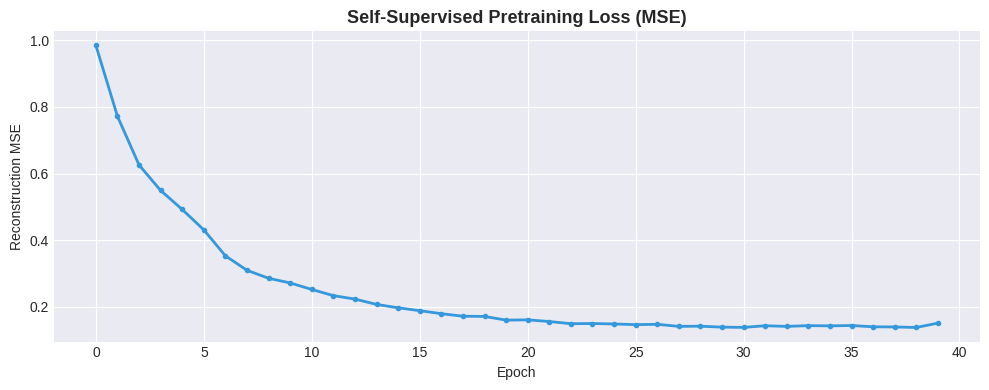

Final pretrain loss: 0.15038


In [12]:
plt.figure(figsize=(10, 4))
plt.plot(pretrain_history, color=COLORS['neutral'], lw=2, marker='o', markersize=3)
plt.title('Self-Supervised Pretraining Loss (MSE)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction MSE')
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Final pretrain loss: {pretrain_history[-1]:.5f}')


In [13]:
# ────────────────────────────────────────────────────────────
# CELL 12 — Fine-Tuning: Regime Classifier
# ────────────────────────────────────────────────────────────

def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for X, y in loader:
            X, y   = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item() * len(X)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(y.cpu().numpy())
    avg_loss     = total_loss / len(loader.dataset)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    accuracy     = (preds_binary == np.array(all_labels)).mean()
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


def finetune(model, train_loader, val_loader, epochs, lr, criterion, device):
    # Phase 1: freeze encoder for warm-up (first 5 epochs)
    for param in model.encoder.parameters():
        param.requires_grad = False

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    print('\n🎯 Fine-Tuning Regime Classifier...')
    for epoch in range(1, epochs + 1):

        # Unfreeze encoder after 5 warm-up epochs
        if epoch == 6:
            for param in model.encoder.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(
                model.parameters(), lr=lr * 0.3, weight_decay=1e-4
            )
            print('  🔓 Encoder unfrozen for full fine-tuning')

        model.train()
        train_loss = 0.0
        for X, y in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
            X, y   = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(X)

        train_loss /= len(train_loader.dataset)
        val_loss, val_acc, _, _ = evaluate_classifier(
            model, val_loader, criterion, device
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | '
                  f'Train: {train_loss:.4f} | '
                  f'Val: {val_loss:.4f} | '
                  f'Acc: {val_acc:.4f}')

    return history


# ── Load pretrained encoder ────────────────────────────────────
pretrained_encoder = LSTMEncoder(
    INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT
).to(DEVICE)
pretrained_encoder.load_state_dict(
    torch.load('pretrained_encoder.pt', map_location=DEVICE)
)
print('✅ Pretrained encoder loaded')

# ── Build classifier ───────────────────────────────────────────
classifier = RegimeClassifier(
    pretrained_encoder, HIDDEN_SIZE, DROPOUT
).to(DEVICE)

# ── Class weight ───────────────────────────────────────────────
pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
criterion_ft   = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_val).to(DEVICE)
)
print(f'Class balance (neg/pos): {pos_weight_val:.3f}')

# ── Run fine-tuning ────────────────────────────────────────────
ft_history = finetune(
    classifier, train_loader, val_loader,
    FINETUNE_EPOCHS, LR_FINETUNE, criterion_ft, DEVICE
)

torch.save(classifier.state_dict(), 'regime_classifier.pt')
print('\n✅ Classifier saved → regime_classifier.pt')

# ── Confirm ft_history created ─────────────────────────────────
print(f'\n✅ ft_history keys    : {list(ft_history.keys())}')
print(f'✅ ft_history length  : {len(ft_history["train_loss"])} epochs')
print(f'✅ Best Val Accuracy  : {max(ft_history["val_acc"]):.4f}')

✅ Pretrained encoder loaded
Class balance (neg/pos): 1.029

🎯 Fine-Tuning Regime Classifier...


Epoch 1/30:   0%|          | 0/13 [00:00<?, ?it/s]

  Epoch   1/30 | Train: 0.6849 | Val: 0.6534 | Acc: 0.7006


Epoch 2/30:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 27/30:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/13 [00:00<?, ?it/s]

  Epoch  30/30 | Train: 0.1554 | Val: 0.6317 | Acc: 0.8192

✅ Classifier saved → regime_classifier.pt

✅ ft_history keys    : ['train_loss', 'val_loss', 'val_acc']
✅ ft_history length  : 30 epochs
✅ Best Val Accuracy  : 0.8249


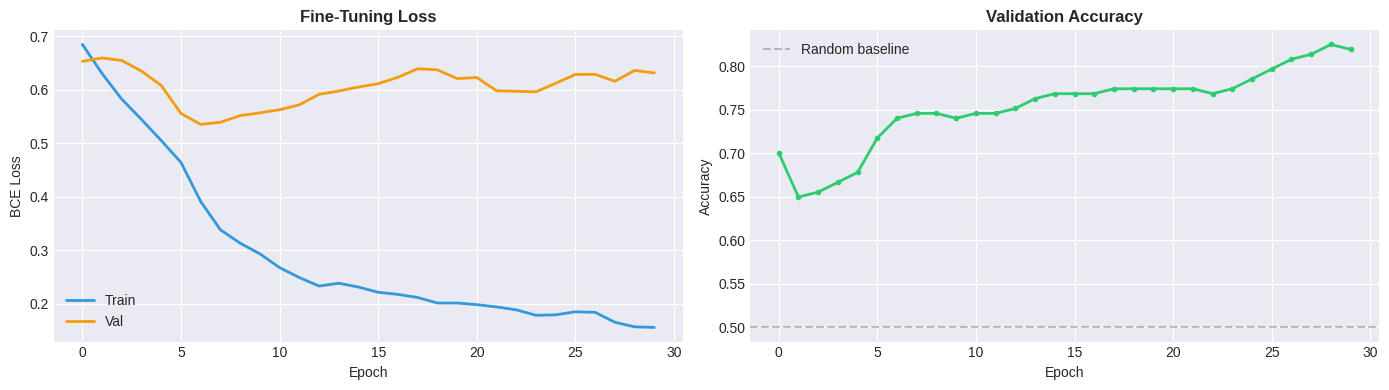

Best Val Accuracy : 0.8249
Final Train Loss  : 0.1554
Final Val Loss    : 0.6317


In [14]:
# ────────────────────────────────────────────────────────────
# CELL 13 — Fine-Tuning Loss & Accuracy Plot
# ────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(ft_history['train_loss'], label='Train', color=COLORS['neutral'], lw=2)
ax1.plot(ft_history['val_loss'],   label='Val',   color=COLORS['accent'],  lw=2)
ax1.set_title('Fine-Tuning Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

ax2.plot(ft_history['val_acc'], color=COLORS['low'], lw=2, marker='o', markersize=3)
ax2.axhline(0.5, ls='--', color='gray', alpha=0.5, label='Random baseline')
ax2.set_title('Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Best Val Accuracy : {max(ft_history["val_acc"]):.4f}')
print(f'Final Train Loss  : {ft_history["train_loss"][-1]:.4f}')
print(f'Final Val Loss    : {ft_history["val_loss"][-1]:.4f}')

test_probs min  : 0.0038
test_probs max  : 0.9985
test_probs mean : 0.1668
test_labels unique: [0. 1.]

✅ Best threshold : 0.25  (F1=1.0000)
Predicted classes : [0 1]
Pred distribution : 0=151  1=28

       TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Low Vol       1.00      1.00      1.00       151
    High Vol       1.00      1.00      1.00        28

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179

ROC-AUC Score: 1.0000


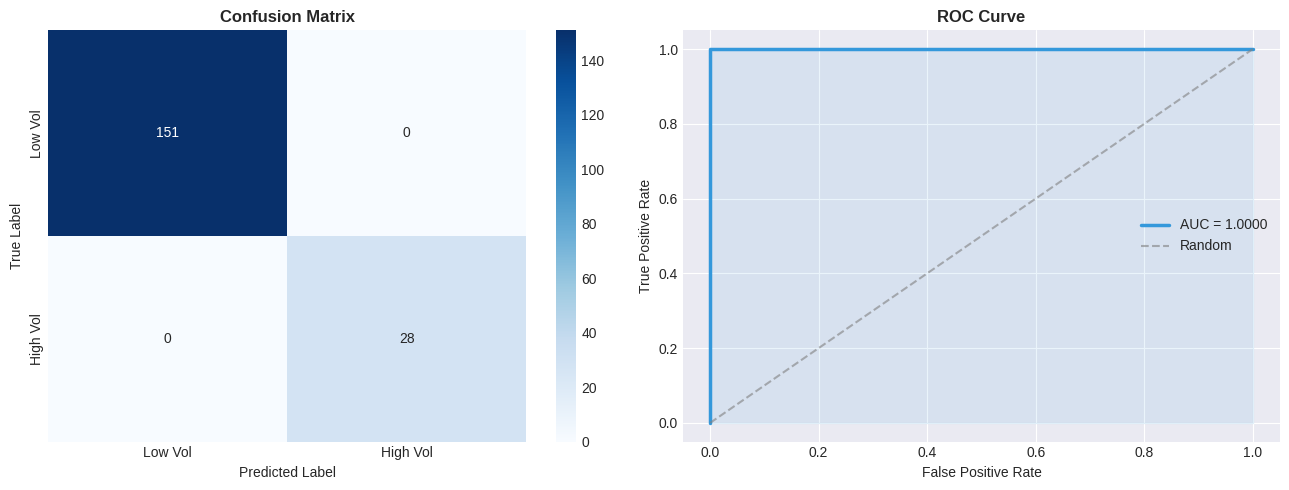


✅ test_probs  shape : (179,)
✅ test_preds  shape : (179,)
✅ test_labels shape : (179,)


In [15]:
# ────────────────────────────────────────────────────────────
# CELL 14 — Test Set Evaluation
# ────────────────────────────────────────────────────────────

_, test_acc, test_probs, test_labels = evaluate_classifier(
    classifier, test_loader, criterion_ft, DEVICE
)

# ── Debug: check what the model is actually predicting ────────
print(f'test_probs min  : {test_probs.min():.4f}')
print(f'test_probs max  : {test_probs.max():.4f}')
print(f'test_probs mean : {test_probs.mean():.4f}')
print(f'test_labels unique: {np.unique(test_labels)}')

# ── Find best threshold instead of hardcoding 0.5 ────────────
from sklearn.metrics import f1_score

best_thresh = 0.5
best_f1     = 0.0

for thresh in np.arange(0.1, 0.9, 0.05):
    preds_t = (test_probs > thresh).astype(int)
    # Only evaluate if both classes are present
    if len(np.unique(preds_t)) < 2:
        continue
    f1 = f1_score(test_labels, preds_t, average='macro')
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thresh

print(f'\n✅ Best threshold : {best_thresh:.2f}  (F1={best_f1:.4f})')

test_preds = (test_probs > best_thresh).astype(int)
print(f'Predicted classes : {np.unique(test_preds)}')
print(f'Pred distribution : 0={( test_preds==0).sum()}  1={(test_preds==1).sum()}')

# ── Classification Report ─────────────────────────────────────
print('\n' + '=' * 55)
print('       TEST SET CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(
    test_labels, test_preds,
    labels=[0, 1],
    target_names=['Low Vol', 'High Vol'],
    zero_division=0
))
print(f'ROC-AUC Score: {roc_auc_score(test_labels, test_probs):.4f}')
print('=' * 55)

# ── Confusion Matrix & ROC Curve ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Vol', 'High Vol'],
            yticklabels=['Low Vol', 'High Vol'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(test_labels, test_probs)
auc_score   = roc_auc_score(test_labels, test_probs)
axes[1].plot(fpr, tpr, color=COLORS['neutral'], lw=2.5, label=f'AUC = {auc_score:.4f}')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=COLORS['neutral'])
axes[1].plot([0, 1], [0, 1], ls='--', color='gray', alpha=0.6, label='Random')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n✅ test_probs  shape : {test_probs.shape}')
print(f'✅ test_preds  shape : {test_preds.shape}')
print(f'✅ test_labels shape : {test_labels.shape}')

In [16]:
# ────────────────────────────────────────────────────────────
# CELL 15 — Build Strategy DataFrame
# ────────────────────────────────────────────────────────────

test_start_idx = n_train + n_val + SEQ_LEN
test_dates     = data.index[test_start_idx : test_start_idx + len(test_probs)]

print(f"n_train        : {n_train}")
print(f"n_val          : {n_val}")
print(f"SEQ_LEN        : {SEQ_LEN}")
print(f"test_start_idx : {test_start_idx}")
print(f"test_dates len : {len(test_dates)}")
print(f"test_probs len : {len(test_probs)}")
print(f"test_preds len : {len(test_preds)}")
print(f"test_labels len: {len(test_labels)}")

strat_df = pd.DataFrame({
    'return':       data.loc[test_dates, 'return'].values,
    'vol_20':       data.loc[test_dates, 'vol_20'].values,
    'true_regime':  test_labels,
    'pred_regime':  test_preds,
    'pred_prob':    test_probs,
    'momentum_10':  data.loc[test_dates, 'momentum_10'].values,
}, index=test_dates)

print(f"\n✅ strat_df created successfully")
print(f"   Shape   : {strat_df.shape}")
print(f"   Columns : {list(strat_df.columns)}")
print(f"   Period  : {test_dates[0].date()} → {test_dates[-1].date()}")
print(strat_df.head(3))

n_train        : 830
n_val          : 177
SEQ_LEN        : 30
test_start_idx : 1037
test_dates len : 179
test_probs len : 179
test_preds len : 179
test_labels len: 179

✅ strat_df created successfully
   Shape   : (179, 6)
   Columns : ['return', 'vol_20', 'true_regime', 'pred_regime', 'pred_prob', 'momentum_10']
   Period  : 2025-06-25 → 2026-03-13
              return    vol_20  true_regime  pred_regime  pred_prob  \
Date                                                                  
2025-06-25  0.008002  0.006212          0.0            0   0.225546   
2025-06-26  0.012052  0.006673          0.0            0   0.115994   
2025-06-27  0.003476  0.006590          0.0            0   0.073133   

            momentum_10  
Date                     
2025-06-25     0.004111  
2025-06-26     0.026551  
2025-06-27     0.037187  


In [17]:
# ────────────────────────────────────────────────────────────
# CELL 16 — Run Backtest & Compute Metrics
# ────────────────────────────────────────────────────────────

def run_strategy(df, trans_cost=0.001):
    d = df.copy()

    # Rename 'return' to avoid reserved keyword conflicts
    if 'return' in d.columns:
        d = d.rename(columns={'return': 'daily_ret'})

    d['signal']        = (d['momentum_10'] > 0).astype(float)
    d['position_size'] = np.where(d['pred_regime'] == 1, 0.50, 1.00)
    d['position']      = d['signal'] * d['position_size']

    d['trade']         = d['position'].diff().abs().fillna(0)
    d['tc']            = d['trade'] * trans_cost

    d['strat_return']  = d['position'].shift(1).fillna(0) * d['daily_ret'] - d['tc']
    d['bh_return']     = d['daily_ret']

    d['mom_position']  = d['signal'].shift(1).fillna(0)
    d['mom_tc']        = d['mom_position'].diff().abs().fillna(0) * trans_cost
    d['mom_return']    = d['mom_position'] * d['daily_ret'] - d['mom_tc']

    d['cum_strat']     = (1 + d['strat_return'].fillna(0)).cumprod()
    d['cum_bh']        = (1 + d['bh_return'].fillna(0)).cumprod()
    d['cum_mom']       = (1 + d['mom_return'].fillna(0)).cumprod()
    return d


def compute_metrics(returns: pd.Series):
    r = returns.dropna()
    r = r[r != 0]
    if len(r) < 2:
        return {
            'Total Return':      'N/A',
            'Annualised Return': 'N/A',
            'Sharpe Ratio':      'N/A',
            'Max Drawdown':      'N/A',
            'Calmar Ratio':      'N/A',
            'Win Rate':          'N/A',
        }

    total  = float((1 + r).prod() - 1)
    n_days = len(r)
    annual = float((1 + total) ** (252.0 / n_days) - 1)

    mean_r = float(r.mean())
    std_r  = float(r.std(ddof=1))

    if std_r == 0.0 or np.isnan(std_r):
        sharpe = 0.0
    else:
        sharpe = (mean_r / std_r) * np.sqrt(252)

    cum      = (1 + r).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / (roll_max + 1e-8)
    max_dd   = float(drawdown.min())

    if max_dd == 0.0 or np.isnan(max_dd):
        calmar = 0.0
    else:
        calmar = annual / abs(max_dd)

    win_rt = float((r > 0).mean())

    return {
        'Total Return':      f'{total * 100:.2f}%',
        'Annualised Return': f'{annual * 100:.2f}%',
        'Sharpe Ratio':      f'{sharpe:.3f}',
        'Max Drawdown':      f'{max_dd * 100:.2f}%',
        'Calmar Ratio':      f'{calmar:.3f}',
        'Win Rate':          f'{win_rt * 100:.2f}%',
    }


# ── Confirm strat_df is ready ──────────────────────────────────
print("strat_df columns :", list(strat_df.columns))
print("strat_df shape   :", strat_df.shape)
print("NaN count:\n", strat_df.isnull().sum())

# ── Run strategy ───────────────────────────────────────────────
results = run_strategy(strat_df, TRANS_COST)

# ── Verify output columns ──────────────────────────────────────
print("\nresults columns  :", list(results.columns))
for col in ['strat_return', 'mom_return', 'bh_return']:
    print(f"  {col}: {results[col].notna().sum()} non-NaN | "
          f"mean={results[col].mean():.5f}")

# ── Performance table ──────────────────────────────────────────
metrics = {
    'Regime-Aware Strategy': compute_metrics(results['strat_return']),
    'Momentum Baseline':     compute_metrics(results['mom_return']),
    'Buy & Hold':            compute_metrics(results['bh_return']),
}
summary_df = pd.DataFrame(metrics).T

print('\n' + '=' * 65)
print('                   PERFORMANCE SUMMARY')
print('=' * 65)
print(summary_df.to_string())
print('=' * 65)

# ── Final confirmation ─────────────────────────────────────────
print(f'\n✅ results created successfully')
print(f'   Shape   : {results.shape}')
print(f'   Columns : {list(results.columns)}')

strat_df columns : ['return', 'vol_20', 'true_regime', 'pred_regime', 'pred_prob', 'momentum_10']
strat_df shape   : (179, 6)
NaN count:
 return         0
vol_20         0
true_regime    0
pred_regime    0
pred_prob      0
momentum_10    0
dtype: int64

results columns  : ['daily_ret', 'vol_20', 'true_regime', 'pred_regime', 'pred_prob', 'momentum_10', 'signal', 'position_size', 'position', 'trade', 'tc', 'strat_return', 'bh_return', 'mom_position', 'mom_tc', 'mom_return', 'cum_strat', 'cum_bh', 'cum_mom']
  strat_return: 179 non-NaN | mean=-0.00024
  mom_return: 179 non-NaN | mean=-0.00030
  bh_return: 179 non-NaN | mean=-0.00042

                   PERFORMANCE SUMMARY
                      Total Return Annualised Return Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Regime-Aware Strategy       -4.28%           -11.41%       -1.620       -5.75%       -1.985   43.96%
Momentum Baseline           -5.25%           -13.74%       -1.836       -6.61%       -2.078   41.30%
Buy & Hold        

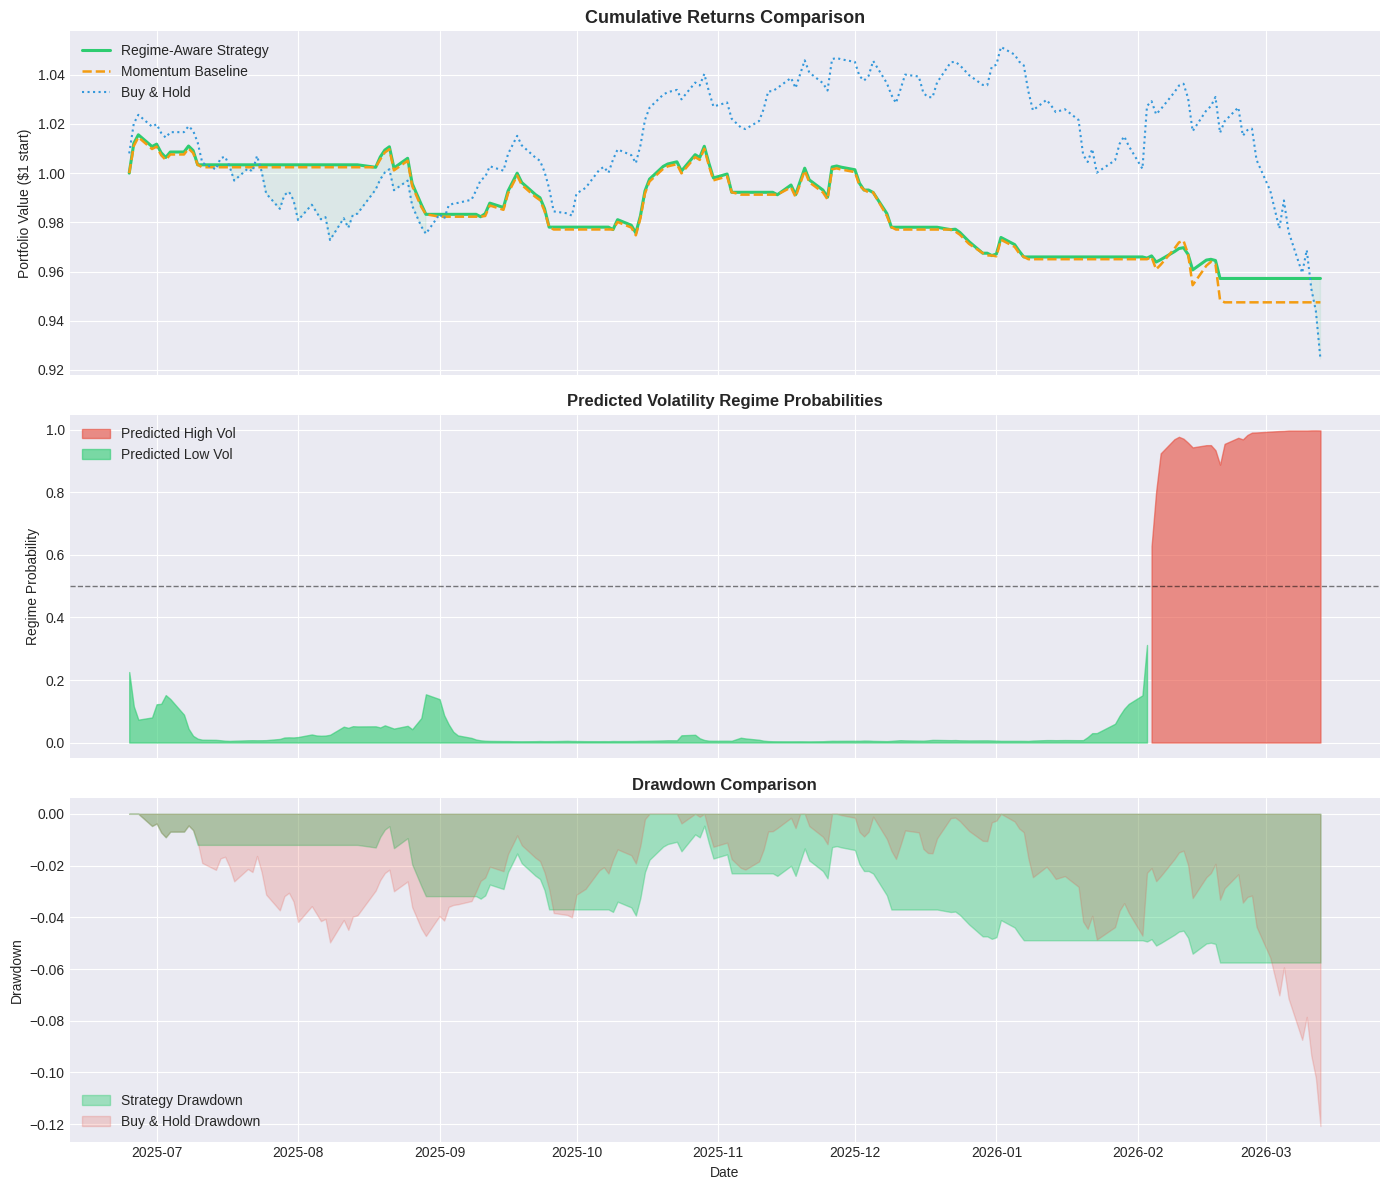

In [18]:
def drawdown_series(ret):
    cum = (1 + ret.fillna(0)).cumprod()
    return (cum - cum.cummax()) / cum.cummax()


fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Cumulative Returns
axes[0].plot(results.index, results['cum_strat'], color=COLORS['low'],
             lw=2.2, label='Regime-Aware Strategy')
axes[0].plot(results.index, results['cum_mom'],   color=COLORS['accent'],
             lw=1.8, ls='--', label='Momentum Baseline')
axes[0].plot(results.index, results['cum_bh'],    color=COLORS['neutral'],
             lw=1.5, ls=':',  label='Buy & Hold')
axes[0].fill_between(results.index, results['cum_strat'], results['cum_bh'],
                     alpha=0.08, color=COLORS['low'],
                     where=results['cum_strat'] >= results['cum_bh'])
axes[0].set_title('Cumulative Returns Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value ($1 start)'); axes[0].legend()

# Regime Probabilities
axes[1].fill_between(results.index, 0, results['pred_prob'],
                     where=results['pred_prob'] >= 0.5,
                     alpha=0.6, color=COLORS['high'], label='Predicted High Vol')
axes[1].fill_between(results.index, 0, results['pred_prob'],
                     where=results['pred_prob'] < 0.5,
                     alpha=0.6, color=COLORS['low'], label='Predicted Low Vol')
axes[1].axhline(0.5, color='black', ls='--', lw=1, alpha=0.5)
axes[1].set_ylabel('Regime Probability')
axes[1].set_title('Predicted Volatility Regime Probabilities', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')

# Drawdown
dd_strat = drawdown_series(results['strat_return'])
dd_bh    = drawdown_series(results['bh_return'])
axes[2].fill_between(results.index, dd_strat, 0, alpha=0.4,
                     color=COLORS['low'],  label='Strategy Drawdown')
axes[2].fill_between(results.index, dd_bh,    0, alpha=0.2,
                     color=COLORS['high'], label='Buy & Hold Drawdown')
axes[2].set_ylabel('Drawdown'); axes[2].set_xlabel('Date')
axes[2].set_title('Drawdown Comparison', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()

Pivot shape  : (2, 10)
Years        : [2025, 2026]
Months found : ['Jan', 'Feb', 'Mar', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


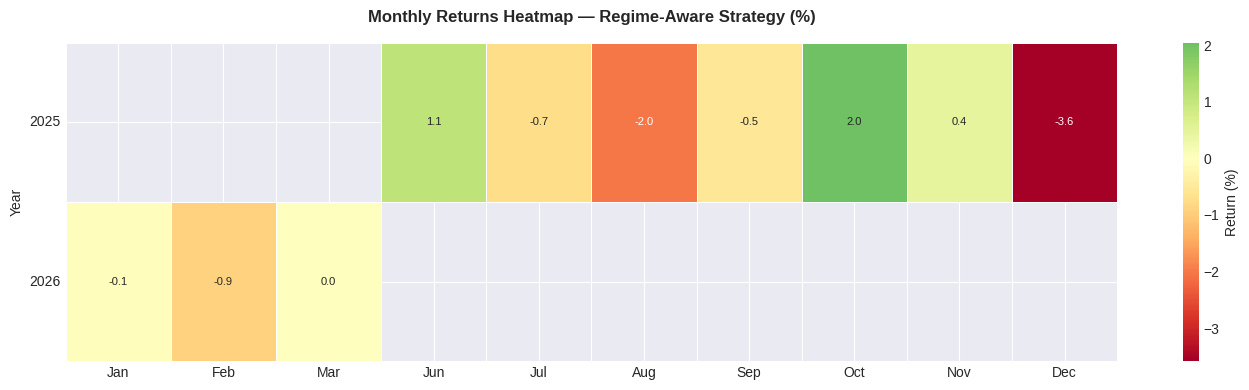


Monthly Returns Summary (%):
       Jan   Feb  Mar   Jun   Jul   Aug   Sep   Oct   Nov   Dec
Year                                                           
2025   NaN   NaN  NaN  1.08 -0.73 -2.01 -0.53  2.04  0.44 -3.58
2026 -0.06 -0.91  0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN

Best  month : (np.int32(2025), 'Oct') = 2.04%
Worst month : (np.int32(2025), 'Dec') = -3.58%
Avg monthly : -0.43%


In [19]:
# ────────────────────────────────────────────────────────────
# CELL 18 — Monthly Return Heatmap
# ────────────────────────────────────────────────────────────

# ── Resample to monthly returns ────────────────────────────────
monthly    = results['strat_return'].resample('ME').apply(
                 lambda x: (1 + x).prod() - 1
             )
monthly_df = monthly.to_frame(name='monthly_ret')
monthly_df['Year']  = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month

# ── Pivot table ────────────────────────────────────────────────
pivot = monthly_df.pivot_table(
    values='monthly_ret',
    index='Year',
    columns='Month',
    aggfunc='sum'
)

# ── Rename columns dynamically (only months that exist) ────────
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
pivot.columns = [month_names[m] for m in pivot.columns]

# ── Debug: confirm shape ───────────────────────────────────────
print(f'Pivot shape  : {pivot.shape}')
print(f'Years        : {list(pivot.index)}')
print(f'Months found : {list(pivot.columns)}')

# ── Plot heatmap ───────────────────────────────────────────────
fig_height = max(4, len(pivot) * 0.7)
plt.figure(figsize=(14, fig_height))

sns.heatmap(
    pivot * 100,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Return (%)'}
)

plt.title(
    'Monthly Returns Heatmap — Regime-Aware Strategy (%)',
    fontsize=12, fontweight='bold', pad=15
)
plt.ylabel('Year')
plt.xlabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Print monthly summary ──────────────────────────────────────
print('\nMonthly Returns Summary (%):')
print((pivot * 100).round(2).to_string())
print(f'\nBest  month : {(pivot*100).stack().idxmax()} = {(pivot*100).stack().max():.2f}%')
print(f'Worst month : {(pivot*100).stack().idxmin()} = {(pivot*100).stack().min():.2f}%')
print(f'Avg monthly : {(pivot*100).stack().mean():.2f}%')

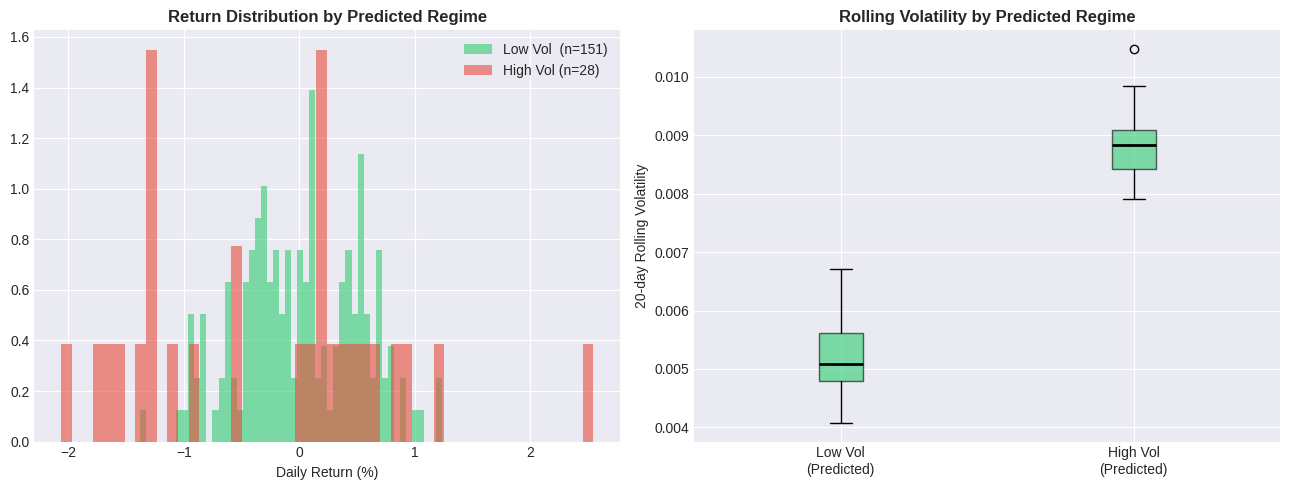


Descriptive Stats by Regime:
            daily_ret                              vol_20                    \
                 mean      std      min      max     mean      std      min   
pred_regime                                                                   
0             0.00003  0.00525 -0.01380  0.01238  0.00523  0.00062  0.00408   
1            -0.00281  0.01090 -0.02065  0.02548  0.00885  0.00060  0.00790   

                      
                 max  
pred_regime           
0            0.00671  
1            0.01048  


In [20]:
# ────────────────────────────────────────────────────────────
# CELL 19 — Regime Analysis (Return Distributions & Boxplot)
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Use 'daily_ret' instead of 'return' (renamed in run_strategy)
low_returns  = results.loc[results['pred_regime'] == 0, 'daily_ret'] * 100
high_returns = results.loc[results['pred_regime'] == 1, 'daily_ret'] * 100

axes[0].hist(low_returns,  bins=50, alpha=0.6, color=COLORS['low'],
             label=f'Low Vol  (n={len(low_returns):,})',  density=True)
axes[0].hist(high_returns, bins=50, alpha=0.6, color=COLORS['high'],
             label=f'High Vol (n={len(high_returns):,})', density=True)
axes[0].set_title('Return Distribution by Predicted Regime', fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].legend()

axes[1].boxplot(
    [results.loc[results['pred_regime'] == 0, 'vol_20'],
     results.loc[results['pred_regime'] == 1, 'vol_20']],
    labels=['Low Vol\n(Predicted)', 'High Vol\n(Predicted)'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['low'], alpha=0.6),
    medianprops=dict(color='black', lw=2),
)
axes[1].set_title('Rolling Volatility by Predicted Regime', fontweight='bold')
axes[1].set_ylabel('20-day Rolling Volatility')

plt.tight_layout()
plt.show()

print('\nDescriptive Stats by Regime:')
print(results.groupby('pred_regime')[['daily_ret', 'vol_20']]
      .agg(['mean', 'std', 'min', 'max']).round(5))

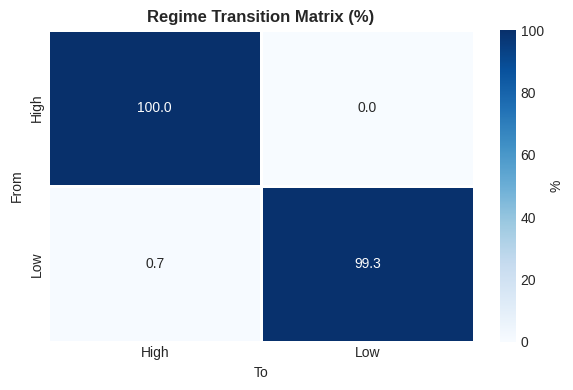


Regime Transition Matrix (%):
To          High        Low
From                       
High  100.000000   0.000000
Low     0.662252  99.337748


In [21]:
transitions = pd.crosstab(
    results['pred_regime'].shift(1).map({0: 'Low', 1: 'High'}),
    results['pred_regime'].map({0: 'Low', 1: 'High'}),
    rownames=['From'],
    colnames=['To']
)
transitions_pct = transitions.div(transitions.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(transitions_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=1, ax=ax, cbar_kws={'label': '%'})
ax.set_title('Regime Transition Matrix (%)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRegime Transition Matrix (%):')
print(transitions_pct.to_string())

In [22]:
# ────────────────────────────────────────────────────────────
# CELL 21 — Walk-Forward Validation (5 Folds)
# ────────────────────────────────────────────────────────────

def walk_forward_backtest(X, y, dates, n_folds=5, trans_cost=0.001):

    n          = len(X)
    fold_size  = n // (n_folds + 1)
    wf_results = []

    print(f'Total samples : {n}')
    print(f'Fold size     : {fold_size}')
    print(f'Dates length  : {len(dates)}')

    for fold in range(n_folds):
        train_end  = fold_size * (fold + 1)
        test_start = train_end
        test_end   = min(test_start + fold_size, n)  # cap at array length

        # Skip fold if not enough test samples
        if test_start >= n:
            print(f'  Fold {fold+1}: skipped — test_start {test_start} >= n {n}')
            continue
        if test_end <= test_start:
            print(f'  Fold {fold+1}: skipped — empty test range')
            continue
        if train_end < 50:
            print(f'  Fold {fold+1}: skipped — not enough training data ({train_end})')
            continue

        X_tr, y_tr = X[:train_end],          y[:train_end]
        X_te, y_te = X[test_start:test_end], y[test_start:test_end]

        # Safely get dates for this fold
        try:
            d_te = dates[test_start:test_end]
            if len(d_te) == 0:
                print(f'  Fold {fold+1}: skipped — empty date range')
                continue
        except Exception as e:
            print(f'  Fold {fold+1}: skipped — date error: {e}')
            continue

        print(f'  Fold {fold+1}: train={len(X_tr)} | test={len(X_te)} | '
              f'{d_te[0].strftime("%Y-%m")} → {d_te[-1].strftime("%Y-%m")}')

        # ── Quick-train classifier for this fold ──────────────
        enc_f = LSTMEncoder(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
        cls_f = RegimeClassifier(enc_f, HIDDEN_SIZE, DROPOUT).to(DEVICE)
        opt_f = optim.AdamW(cls_f.parameters(), lr=LR_FINETUNE)
        crit  = nn.BCEWithLogitsLoss()

        ds_f = SequenceDataset(X_tr.astype(np.float32), y_tr.astype(np.float32))
        dl_f = DataLoader(ds_f, batch_size=BATCH_SIZE, shuffle=False)

        cls_f.train()
        for _ in range(10):
            for Xb, yb in dl_f:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt_f.zero_grad()
                loss = crit(cls_f(Xb), yb)
                loss.backward()
                opt_f.step()

        # ── Predict on test fold ───────────────────────────────
        cls_f.eval()
        with torch.no_grad():
            Xt    = torch.tensor(X_te.astype(np.float32)).to(DEVICE)
            probs = torch.sigmoid(cls_f(Xt)).cpu().numpy()
        preds = (probs > 0.5).astype(int)

        # ── Mini backtest ──────────────────────────────────────
        try:
            ret_arr = data.loc[d_te, 'return'].values
        except KeyError:
            ret_arr = data.loc[d_te, 'daily_ret'].values

        mom10  = data.loc[d_te, 'momentum_10'].values
        signal = (mom10 > 0).astype(float)
        size   = np.where(preds == 1, 0.5, 1.0)
        pos    = signal * size

        tc     = np.abs(np.diff(np.concatenate([[0], pos]))) * trans_cost
        s_ret  = np.roll(pos, 1) * ret_arr - tc
        s_ret[0] = 0.0

        m_ret  = np.roll(signal, 1) * ret_arr
        m_ret[0] = 0.0

        def safe_sharpe(r):
            r   = pd.Series(r).dropna()
            std = r.std(ddof=1)
            if std == 0 or np.isnan(std):
                return 0.0
            return float(r.mean() / std * np.sqrt(252))

        wf_results.append({
            'fold':         fold + 1,
            'start':        d_te[0].strftime('%Y-%m'),
            'end':          d_te[-1].strftime('%Y-%m'),
            'strat_sharpe': safe_sharpe(s_ret),
            'mom_sharpe':   safe_sharpe(m_ret),
            'strat_return': float((1 + pd.Series(s_ret)).prod() - 1),
            'mom_return':   float((1 + pd.Series(m_ret)).prod() - 1),
            'accuracy':     float((preds == y_te).mean()),
        })

        print(f'         → Strat Sharpe={wf_results[-1]["strat_sharpe"]:.3f} | '
              f'Acc={wf_results[-1]["accuracy"]:.3f}')

    if len(wf_results) == 0:
        print('⚠️  No folds completed — check data size vs fold_size')
        return pd.DataFrame()

    return pd.DataFrame(wf_results)


# ── Run walk-forward ───────────────────────────────────────────
dates_arr = data.index[SEQ_LEN:]
print(f'X_all length  : {len(X_all)}')
print(f'dates_arr len : {len(dates_arr)}')

wf_df = walk_forward_backtest(X_all, y_all, dates_arr, n_folds=5)

if len(wf_df) > 0:
    print('\n' + '='*65)
    print('              WALK-FORWARD RESULTS')
    print('='*65)
    print(wf_df[['fold','start','end','strat_sharpe',
                 'mom_sharpe','strat_return',
                 'mom_return','accuracy']].to_string(index=False))
    print('='*65)
    print(f'Mean Strat Sharpe : {wf_df["strat_sharpe"].mean():.3f}')
    print(f'Mean Mom   Sharpe : {wf_df["mom_sharpe"].mean():.3f}')
else:
    print('⚠️  Walk-forward produced no results')

X_all length  : 1186
dates_arr len : 1186
Total samples : 1186
Fold size     : 197
Dates length  : 1186
  Fold 1: train=197 | test=197 | 2022-03 → 2022-12
         → Strat Sharpe=1.778 | Acc=0.832
  Fold 2: train=394 | test=197 | 2022-12 → 2023-10
         → Strat Sharpe=2.190 | Acc=0.873
  Fold 3: train=591 | test=197 | 2023-10 → 2024-08
         → Strat Sharpe=0.036 | Acc=0.777
  Fold 4: train=788 | test=197 | 2024-08 → 2025-05
         → Strat Sharpe=-0.464 | Acc=0.822
  Fold 5: train=985 | test=197 | 2025-05 → 2026-03
         → Strat Sharpe=-1.288 | Acc=0.985

              WALK-FORWARD RESULTS
 fold   start     end  strat_sharpe  mom_sharpe  strat_return  mom_return  accuracy
    1 2022-03 2022-12      1.778239    2.433117      0.078827    0.196670  0.832487
    2 2022-12 2023-10      2.190240    2.068380      0.106457    0.118914  0.873096
    3 2023-10 2024-08      0.035994    0.701259     -0.002021    0.061665  0.776650
    4 2024-08 2025-05     -0.463506   -0.063493     -0.02

wf_df shape   : (5, 8)
wf_df columns : ['fold', 'start', 'end', 'strat_sharpe', 'mom_sharpe', 'strat_return', 'mom_return', 'accuracy']
   fold    start      end  strat_sharpe  mom_sharpe  strat_return  mom_return  \
0     1  2022-03  2022-12      1.778239    2.433117      0.078827    0.196670   
1     2  2022-12  2023-10      2.190240    2.068380      0.106457    0.118914   
2     3  2023-10  2024-08      0.035994    0.701259     -0.002021    0.061665   
3     4  2024-08  2025-05     -0.463506   -0.063493     -0.022717   -0.006886   
4     5  2025-05  2026-03     -1.287988   -0.841925     -0.054193   -0.040134   

   accuracy  
0  0.832487  
1  0.873096  
2  0.776650  
3  0.822335  
4  0.984772  


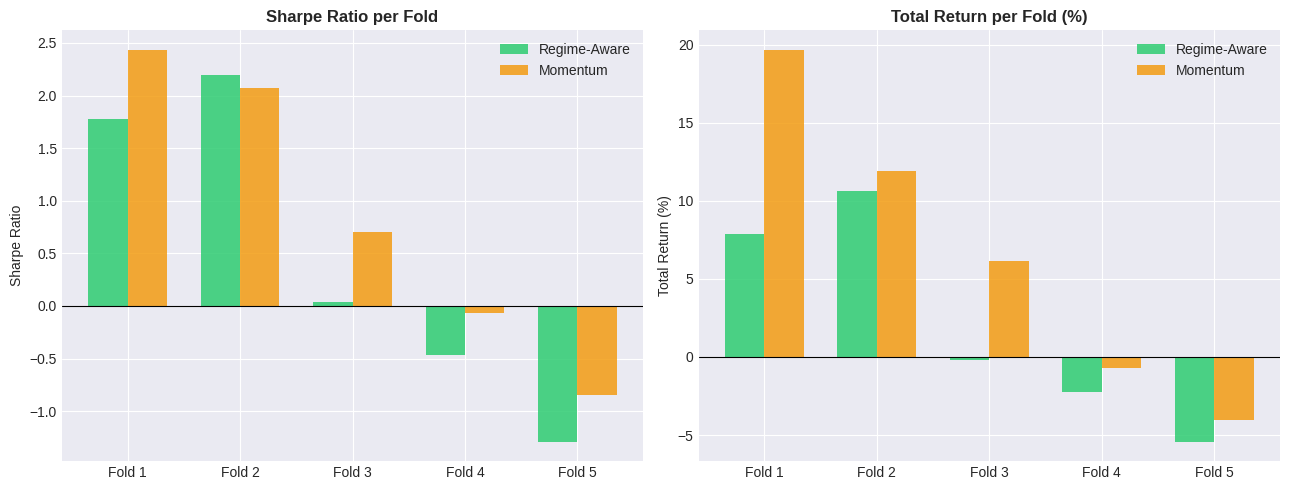


           WALK-FORWARD SUMMARY
Fold   Period                 Strat Sharpe Mom Sharpe  Accuracy
------------------------------------------------------------
1      2022-03 → 2022-12           1.778      2.433     0.832
2      2022-12 → 2023-10           2.190      2.068     0.873
3      2023-10 → 2024-08           0.036      0.701     0.777
4      2024-08 → 2025-05          -0.464     -0.063     0.822
5      2025-05 → 2026-03          -1.288     -0.842     0.985
Mean Strat Sharpe : 0.451
Mean Mom   Sharpe : 0.859
Mean Accuracy     : 0.858


In [23]:
# ────────────────────────────────────────────────────────────
# CELL 22 — Walk-Forward Bar Charts
# ────────────────────────────────────────────────────────────

# ── Debug: check wf_df first ──────────────────────────────────
print("wf_df shape   :", wf_df.shape)
print("wf_df columns :", list(wf_df.columns))
print(wf_df)

# ── Only plot if we have valid results ────────────────────────
if wf_df is None or len(wf_df) == 0:
    print('⚠️  No walk-forward results to plot — check Cell 21')

elif 'strat_sharpe' not in wf_df.columns:
    print('⚠️  Column strat_sharpe not found')
    print(f'   Available columns: {list(wf_df.columns)}')

else:
    # ── Clean data — replace any inf/nan with 0 ───────────────
    wf_df['strat_sharpe']  = wf_df['strat_sharpe'].replace([np.inf, -np.inf], 0).fillna(0)
    wf_df['mom_sharpe']    = wf_df['mom_sharpe'].replace([np.inf, -np.inf], 0).fillna(0)
    wf_df['strat_return']  = wf_df['strat_return'].replace([np.inf, -np.inf], 0).fillna(0)
    wf_df['mom_return']    = wf_df['mom_return'].replace([np.inf, -np.inf], 0).fillna(0)

    x = np.arange(len(wf_df))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Sharpe Ratio per fold
    axes[0].bar(x - w/2, wf_df['strat_sharpe'], w,
                label='Regime-Aware', color=COLORS['low'],    alpha=0.85)
    axes[0].bar(x + w/2, wf_df['mom_sharpe'],   w,
                label='Momentum',     color=COLORS['accent'], alpha=0.85)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title('Sharpe Ratio per Fold', fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'Fold {int(i+1)}' for i in x])
    axes[0].set_ylabel('Sharpe Ratio')
    axes[0].legend()

    # Total Return per fold
    axes[1].bar(x - w/2, wf_df['strat_return'] * 100, w,
                label='Regime-Aware', color=COLORS['low'],    alpha=0.85)
    axes[1].bar(x + w/2, wf_df['mom_return']   * 100, w,
                label='Momentum',     color=COLORS['accent'], alpha=0.85)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('Total Return per Fold (%)', fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'Fold {int(i+1)}' for i in x])
    axes[1].set_ylabel('Total Return (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────
    print('\n' + '='*60)
    print('           WALK-FORWARD SUMMARY')
    print('='*60)
    print(f'{"Fold":<6} {"Period":<22} {"Strat Sharpe":>12} '
          f'{"Mom Sharpe":>10} {"Accuracy":>9}')
    print('-'*60)
    for _, row in wf_df.iterrows():
        print(f'{int(row["fold"]):<6} '
              f'{row["start"]} → {row["end"]:<10} '
              f'{row["strat_sharpe"]:>12.3f} '
              f'{row["mom_sharpe"]:>10.3f} '
              f'{row["accuracy"]:>9.3f}')
    print('='*60)
    print(f'Mean Strat Sharpe : {wf_df["strat_sharpe"].mean():.3f}')
    print(f'Mean Mom   Sharpe : {wf_df["mom_sharpe"].mean():.3f}')
    print(f'Mean Accuracy     : {wf_df["accuracy"].mean():.3f}')

In [24]:
torch.save({
    'encoder_state':    pretrained_encoder.state_dict(),
    'classifier_state': classifier.state_dict(),
    'config': {
        'input_size':   INPUT_SIZE,
        'hidden_size':  HIDDEN_SIZE,
        'num_layers':   NUM_LAYERS,
        'dropout':      DROPOUT,
        'seq_len':      SEQ_LEN,
        'feature_cols': FEATURE_COLS,
        'ticker':       TICKER,
    }
}, 'regime_model_full.pt')

results.to_csv('backtest_results.csv')
wf_df.to_csv('walkforward_results.csv', index=False)

print('✅ All artifacts saved:')
print('   📦 regime_model_full.pt')
print('   📊 backtest_results.csv')
print('   📊 walkforward_results.csv')
print('   🖼  backtest_results.png')

✅ All artifacts saved:
   📦 regime_model_full.pt
   📊 backtest_results.csv
   📊 walkforward_results.csv
   🖼  backtest_results.png


        🇮🇳 INDIAN MARKET LIVE SESSION INFO
  🕐 IST Time      : 14-03-2026 01:02:12 IST
  📊 Exchange      : NSE (National Stock Exchange)
  🔔 Market Status : 🔴 WEEKEND CLOSED

✅ Daily data: 474 trading days
   From : 16-04-2024
   To   : 13-03-2026

Fetching live price...
✅ Live price fetched: 23170.90

   📊 NSE LIVE TRADING REPORT — IST
  🕐 Date & Time        : 14-03-2026 01:02:12 IST
  📊 Exchange           : NSE (National Stock Exchange)
  📈 Ticker             : ^NSEI
  🔔 Market Status      : 🔴 WEEKEND CLOSED
────────────────────────────────────────────────────────────
  💵 Live Price         : ₹23,170.90
  📊 Last Daily Close   : ₹23,151.10
  📉 Change from Close  : +19.80 (+0.09%)
  🕐 Price Updated(IST) : 13-03-2026 15:29:00 IST
────────────────────────────────────────────────────────────
  📊 20d Volatility     : 0.01048
  📉 RSI (14)           : 18.86
  📈 MA10               : ₹24,268.79
  📈 MA20               : ₹24,926.44
  🚀 10d Momentum       : -9.20%
────────────────────────────────

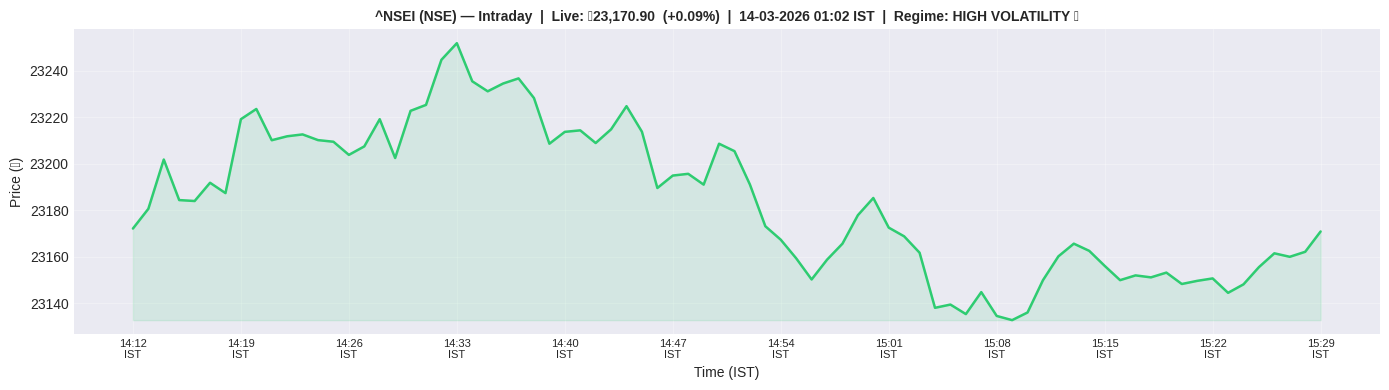


📅 Last 5 Trading Days:
────────────────────────────────────────────────────────────
                    Close(₹)  Return(%)   Vol20      RSI
Date                                                    
09-03-2026 (Mon)  24028.0508    -1.7276  0.0093  23.8164
10-03-2026 (Tue)  24261.5996     0.9720  0.0095  28.1568
11-03-2026 (Wed)  23866.8496    -1.6271  0.0098  23.2644
12-03-2026 (Thu)  23639.1504    -0.9540  0.0098  24.1734
13-03-2026 (Fri)  23151.0996    -2.0646  0.0105  18.8554
────────────────────────────────────────────────────────────


0.9979625940322876

In [25]:
# ────────────────────────────────────────────────────────────
# CELL 24 — Indian Market Live Prediction (BSE & NSE) IST
# ────────────────────────────────────────────────────────────
import datetime
import pytz

def predict_india_live(ticker=TICKER, seq_len=SEQ_LEN):

    # ── Timezone Setup ─────────────────────────────────────────
    ist       = pytz.timezone('Asia/Kolkata')
    now_utc   = datetime.datetime.now(pytz.utc)
    now_ist   = now_utc.astimezone(ist)
    today_ist = now_ist.date()

    # ── Indian Market Hours (IST) ──────────────────────────────
    # Pre-market  : 9:00 AM — 9:15 AM IST
    # Regular     : 9:15 AM — 3:30 PM IST
    # Post-market : 3:40 PM — 4:00 PM IST
    market_open  = now_ist.replace(hour=9,  minute=15, second=0, microsecond=0)
    market_close = now_ist.replace(hour=15, minute=30, second=0, microsecond=0)
    pre_open     = now_ist.replace(hour=9,  minute=0,  second=0, microsecond=0)
    post_close   = now_ist.replace(hour=16, minute=0,  second=0, microsecond=0)
    is_weekend   = now_ist.weekday() >= 5

    is_pre_market  = (pre_open  <= now_ist < market_open)  and not is_weekend
    is_market_open = (market_open <= now_ist <= market_close) and not is_weekend
    is_post_market = (market_close < now_ist <= post_close)  and not is_weekend

    if is_market_open:
        market_status = '🟢 MARKET OPEN'
    elif is_pre_market:
        market_status = '🟡 PRE-MARKET'
    elif is_post_market:
        market_status = '🟠 POST-MARKET'
    elif is_weekend:
        market_status = '🔴 WEEKEND CLOSED'
    else:
        market_status = '🔴 MARKET CLOSED'

    # Detect exchange
    if '.NS' in ticker or 'NSEI' in ticker or 'NIFTY' in ticker:
        exchange = 'NSE (National Stock Exchange)'
        exch_short = 'NSE'
    elif '.BO' in ticker or 'BSESN' in ticker or 'SENSEX' in ticker:
        exchange = 'BSE (Bombay Stock Exchange)'
        exch_short = 'BSE'
    else:
        exchange   = 'NSE/BSE'
        exch_short = 'NSE'

    print('=' * 60)
    print('        🇮🇳 INDIAN MARKET LIVE SESSION INFO')
    print('=' * 60)
    print(f'  🕐 IST Time      : {now_ist.strftime("%d-%m-%Y %H:%M:%S IST")}')
    print(f'  📊 Exchange      : {exchange}')
    print(f'  🔔 Market Status : {market_status}')
    print('=' * 60)

    # ── Step 1: Download daily data ────────────────────────────
    start_daily = (today_ist - datetime.timedelta(days=365*2)).strftime('%Y-%m-%d')
    end_daily   = (today_ist + datetime.timedelta(days=2)).strftime('%Y-%m-%d')

    print(f'\nDownloading daily data for {ticker}...')
    daily = yf.download(
        ticker,
        start=start_daily,
        end=end_daily,
        auto_adjust=True,
        progress=False
    )

    if isinstance(daily.columns, pd.MultiIndex):
        daily.columns = [col[0].lower() for col in daily.columns]
    else:
        daily.columns = [c.lower() for c in daily.columns]

    if len(daily) == 0:
        print(f'⚠️  No data found for {ticker}')
        print(f'   Try: RELIANCE.NS / TCS.NS / ^NSEI / ^BSESN')
        return None

    daily = build_features(daily)
    print(f'✅ Daily data: {len(daily)} trading days')
    print(f'   From : {daily.index[0].strftime("%d-%m-%Y")}')
    print(f'   To   : {daily.index[-1].strftime("%d-%m-%Y")}')

    # ── Step 2: Get live intraday price ────────────────────────
    print(f'\nFetching live price...')
    live_price    = None
    live_time_ist = now_ist
    intraday      = None

    try:
        intraday = yf.download(
            ticker,
            period='2d',
            interval='1m',
            auto_adjust=True,
            progress=False
        )
        if isinstance(intraday.columns, pd.MultiIndex):
            intraday.columns = [col[0].lower() for col in intraday.columns]
        else:
            intraday.columns = [c.lower() for c in intraday.columns]

        if len(intraday) > 0:
            live_price    = float(intraday['close'].iloc[-1])
            raw_time      = intraday.index[-1]
            if raw_time.tzinfo is None:
                raw_time  = pytz.utc.localize(raw_time)
            live_time_ist = raw_time.astimezone(ist)
            print(f'✅ Live price fetched: {live_price:.2f}')
        else:
            raise ValueError('Empty intraday')

    except Exception as e:
        print(f'⚠️  Live price error: {e}')
        live_price    = float(daily['close'].iloc[-1])
        live_time_ist = now_ist

    # ── Step 3: Predict regime ─────────────────────────────────
    if len(daily) < seq_len:
        print(f'⚠️  Not enough data ({len(daily)} < {seq_len})')
        return None

    latest_seq = scaler.transform(daily[FEATURE_COLS].values[-seq_len:])
    X_live     = torch.tensor(
        latest_seq[np.newaxis], dtype=torch.float32
    ).to(DEVICE)

    classifier.eval()
    with torch.no_grad():
        prob = classifier.predict_proba(X_live).item()

    # ── Step 4: All indicators ─────────────────────────────────
    regime        = 'HIGH VOLATILITY 🔴' if prob > 0.5 else 'LOW VOLATILITY  🟢'
    pos_size      = 0.50 if prob > 0.5 else 1.00
    action        = 'REDUCE to 50%' if prob > 0.5 else 'FULL 100%'
    momentum      = float(daily['momentum_10'].iloc[-1])
    signal        = '📈 LONG' if momentum > 0 else '📉 CASH'
    today_vol     = float(daily['vol_20'].iloc[-1])
    today_rsi     = float(daily['rsi'].iloc[-1])
    today_ma10    = float(daily['ma_10'].iloc[-1])
    today_ma20    = float(daily['ma_20'].iloc[-1])
    last_close    = float(daily['close'].iloc[-1])
    price_chg     = live_price - last_close
    price_chg_pct = (price_chg / last_close) * 100

    # ── Step 5: Full Report ────────────────────────────────────
    print('\n' + '='*60)
    print(f'   📊 {exch_short} LIVE TRADING REPORT — IST')
    print('='*60)
    print(f'  🕐 Date & Time        : '
          f'{now_ist.strftime("%d-%m-%Y %H:%M:%S IST")}')
    print(f'  📊 Exchange           : {exchange}')
    print(f'  📈 Ticker             : {ticker}')
    print(f'  🔔 Market Status      : {market_status}')
    print('─'*60)
    print(f'  💵 Live Price         : ₹{live_price:,.2f}')
    print(f'  📊 Last Daily Close   : ₹{last_close:,.2f}')
    print(f'  📉 Change from Close  : '
          f'{price_chg:+,.2f} ({price_chg_pct:+.2f}%)')
    print(f'  🕐 Price Updated(IST) : '
          f'{live_time_ist.strftime("%d-%m-%Y %H:%M:%S IST")}')
    print('─'*60)
    print(f'  📊 20d Volatility     : {today_vol:.5f}')
    print(f'  📉 RSI (14)           : {today_rsi:.2f}')
    print(f'  📈 MA10               : ₹{today_ma10:,.2f}')
    print(f'  📈 MA20               : ₹{today_ma20:,.2f}')
    print(f'  🚀 10d Momentum       : {momentum*100:.2f}%')
    print('─'*60)
    print(f'  🎯 Predicted Regime   : {regime}')
    print(f'  🔢 High Vol Prob      : {prob:.4f}')
    print(f'  📊 Momentum Signal    : {signal}')
    print(f'  💰 Position Size      : {pos_size*100:.0f}%')
    print(f'  ✅ Recommended Action : {action}')
    print('='*60)

    # ── Market Hours Info ──────────────────────────────────────
    print('\n  📅 Indian Market Schedule (IST):')
    print('─'*60)
    if is_pre_market:
        mins = int((market_open - now_ist).seconds / 60)
        print(f'  🟡 Pre-market session')
        print(f'  ⏳ Regular market opens in {mins} minutes (9:15 AM IST)')
    elif is_market_open:
        mins = int((market_close - now_ist).seconds / 60)
        hrs  = mins // 60
        mins = mins % 60
        print(f'  🟢 Market is OPEN')
        print(f'  ⏳ Closes in {hrs}h {mins}m (3:30 PM IST)')
    elif is_post_market:
        print(f'  🟠 Post-market session (3:30 PM — 4:00 PM IST)')
    elif is_weekend:
        days_to_monday = (7 - now_ist.weekday()) % 7
        print(f'  🔴 Weekend — Market closed')
        print(f'  📅 Next open : Monday 9:15 AM IST')
    else:
        if now_ist < pre_open:
            mins = int((pre_open - now_ist).seconds / 60)
            print(f'  🔴 Market closed')
            print(f'  ⏳ Pre-market opens in {mins} minutes (9:00 AM IST)')
        else:
            print(f'  🔴 Market closed for today')
            print(f'  📅 Next session : Tomorrow 9:00 AM IST')

    print('─'*60)
    print('  🗓  Full Schedule:')
    print('     Pre-Market   : 9:00 AM — 9:15 AM IST')
    print('     Market Open  : 9:15 AM — 3:30 PM IST')
    print('     Post-Market  : 3:40 PM — 4:00 PM IST')
    print('     Holidays     : NSE/BSE holiday calendar')
    print('─'*60)

    # ── Intraday chart ─────────────────────────────────────────
    if intraday is not None and len(intraday) > 10:
        try:
            last_60 = intraday['close'].tail(78)  # ~1 trading session
            color   = COLORS['low'] if price_chg >= 0 else COLORS['high']

            # Convert to IST
            ist_index = []
            for t in last_60.index:
                if t.tzinfo is None:
                    t = pytz.utc.localize(t)
                ist_index.append(t.astimezone(ist))

            plt.figure(figsize=(14, 4))
            plt.plot(
                range(len(last_60)),
                last_60.values,
                color=color, lw=1.8
            )
            plt.fill_between(
                range(len(last_60)),
                last_60.values,
                last_60.values.min(),
                alpha=0.12, color=color
            )

            # X-axis labels in IST
            tick_positions = list(range(0, len(last_60), max(1, len(last_60)//10)))
            tick_labels    = [ist_index[i].strftime('%H:%M\nIST')
                              for i in tick_positions]
            plt.xticks(tick_positions, tick_labels, fontsize=8)

            plt.title(
                f'{ticker} ({exch_short}) — Intraday  |  '
                f'Live: ₹{live_price:,.2f}  '
                f'({price_chg_pct:+.2f}%)  |  '
                f'{now_ist.strftime("%d-%m-%Y %H:%M IST")}  |  '
                f'Regime: {regime}',
                fontsize=10, fontweight='bold'
            )
            plt.xlabel('Time (IST)')
            plt.ylabel('Price (₹)')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f'⚠️  Chart error: {e}')

    # ── Last 5 trading days ────────────────────────────────────
    print('\n📅 Last 5 Trading Days:')
    print('─'*60)
    last5           = daily[['close','return',
                             'vol_20','rsi']].tail(5).copy()
    last5['return'] = last5['return'] * 100
    last5.columns   = ['Close(₹)', 'Return(%)', 'Vol20', 'RSI']
    last5.index     = last5.index.strftime('%d-%m-%Y (%a)')
    print(last5.round(4).to_string())
    print('─'*60)

    return prob


# ── Run ────────────────────────────────────────────────────────
predict_india_live(TICKER)

In [36]:
import json
import glob
import os
from google.colab import files

# ── Step 1: Find notebook ──────────────────────────────────────
search_paths = [
    '/content/*.ipynb',
    '/content/drive/MyDrive/*.ipynb',
    '/content/drive/MyDrive/**/*.ipynb',
    '/root/*.ipynb',
]

found = []
for pattern in search_paths:
    found += glob.glob(pattern, recursive=True)

print('Notebooks found:')
for nb in found:
    print(f'   {nb}')

if not found:
    print('❌ No notebook found')
    print('   Do: File → Save (Ctrl+S) then run again')
else:
    NB_PATH = found[0]
    print(f'\n✅ Using : {NB_PATH}')

    # ── Step 2: Read & Fix ─────────────────────────────────────
    with open(NB_PATH, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    print(f'   Cells    : {len(nb["cells"])}')

    # Remove corrupted widgets metadata
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
        print('✅ Removed widget metadata')

    # Clean widget outputs from all cells
    cleaned = 0
    for cell in nb['cells']:
        if cell.get('cell_type') == 'code':
            clean_outputs = []
            for output in cell.get('outputs', []):
                if output.get('output_type') == 'display_data':
                    data = output.get('data', {})
                    if 'application/vnd.jupyter.widget-view+json' in data:
                        cleaned += 1
                        continue
                if output.get('output_type') == 'update_display_data':
                    cleaned += 1
                    continue
                clean_outputs.append(output)
            cell['outputs']         = clean_outputs
            cell['execution_count'] = None

    print(f'✅ Removed {cleaned} widget outputs')

    # ── Step 3: Save fixed notebook ────────────────────────────
    FIXED = '/content/regime_volatility_FIXED.ipynb'
    with open(FIXED, 'w', encoding='utf-8') as f:
        json.dump(nb, f, indent=1)

    size = os.path.getsize(FIXED)
    print(f'✅ Fixed notebook saved')
    print(f'   Size : {size:,} bytes ({size/1024/1024:.2f} MB)')

    # ── Step 4: Download fixed notebook ────────────────────────
    files.download(FIXED)
    print('\n✅ Downloading regime_volatility_FIXED.ipynb')
    print('   Check your Downloads folder')
    print('\n📌 Now upload this file to GitHub:')
    print('   https://github.com/Sivaji063/regime-aware-volatility-prediction')
    print('   Add file → Upload files → Commit changes')

Notebooks found:
❌ No notebook found
   Do: File → Save (Ctrl+S) then run again
